Соревнование Kaggle. Есть мультиязычный датасет с двумя полями, которые содержат разные текста на одном языке, необходимо обучить модель классификации, которая по этим двум текстам будет определять отношение между ними. Всего отношений 3: второй текст является следствием первого, текста противоречат друг другу, текста нейтральны. Размер датасета 12000, классы сбалансированы, однако текстов на английском языке на порядок больше (7000)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from huggingface_hub import notebook_login
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# **0. Методы**

In [2]:
#Устройство обучения
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Для вычислений используется {device}')

Для вычислений используется cpu


In [3]:
#Авторизация Hugging Face
notebook_login()

## **0.1. Методы для подготовки данных**

In [4]:
#Методы для работы с текстом
def findSeqEnd(text, separators, max_length):
    """
        Поиск позиции последнего вхождения разделителя из separators по приоритету в часте текста text[:max_length].
    Индекс разделителя в separators задает его приоритет
    Параметры
    --------
    text: str
        Входящий текст

    separators: List
        Приоритетный список разделителей

    max_length: int
        Ограничение по длине обрабатываемого текста
    """
    if not isinstance(text, str):
        raise TypeError('Ожидался тип str для text')
    elif not isinstance(separators, list):
        raise TypeError('Ожидался тип List для separators')
    elif not isinstance(max_length, int):
        raise TypeError('Ожидалось целое число для max_length')

    separators_end = {char: index for index, char in enumerate(text[:max_length])
                                  if char in separators}
    for sep in separators:
        if separators_end.get(sep, 0) > 0:
            return separators_end[sep]
    return max_length

def cutText(text, separators, parts_sep, max_length):
    """
        Сжатие текста до длины <= max_length путем склейки начала и конца предложения с разделителем parts_sep между частями. 
    Если длина текста и так <= max_length, то возвращается исходный текст.
    Параметры
    --------
    text: str
        Входящий текст

    separators: List                              
        Приоритетный список разделителей

    parts_sep: str
        Разделитель между частями

    max_length: int
        Ограничение по длине выводимого текста
    """
    if not isinstance(text, str):
        raise TypeError('Ожидался тип str для text')
    elif not isinstance(parts_sep, str):
        raise TypeError('Ожидался тип str для разделителя между частями')
    elif len(text) <= max_length:
        return text
    else:
        max_length -= len(parts_sep)
        if max_length <= 0:
            raise ValueError('Длина разделителя между частями >= ограничения по длине')
        begin = findSeqEnd(text, separators, int(max_length / 2))
        end = findSeqEnd(text[::-1], separators, int(max_length / 2))
        return text[:begin] + parts_sep + text[-end:]    

In [5]:
#Подготовка premise и hypothesis к обработке моделей
def prepare_data(row, max_length):
    seps, parts_sep = ['.',',',' '], ' ... '
    premise_len, hypothesis_len = len(row['premise']), len(row['hypothesis'])
    if premise_len + hypothesis_len > max_length:
        if premise_len > max_length / 2:
            row['premise'] = cutText(row['premise'], 
                                     seps, 
                                     parts_sep, 
                                     int(max(max_length / 2, max_length - hypothesis_len)))
        if hypothesis_len > max_length / 2:
            row['hypothesis'] = cutText(row['hypothesis'],
                                        seps, 
                                        parts_sep, 
                                        int(max(max_length / 2, max_length - premise_len)))        
    return row

## **0.2. Методы для обучения моделей**

In [6]:
#Токенизатор
def tokenize(tokenizer, batch):
    return tokenizer(batch['premise'],
                     batch['hypothesis'],
                     truncation=True,
                     max_length=512,
                     padding='max_length')

#Подсчет метрик качества
def metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = torch.argmax(logits, dim=-1)
    accuracy = accuracy_score(labels, predictions)
    return {'accuracy': accuracy}

# **1. Загрузка данных**

Обучающий датасет представлен следующими полями:

 1. premise	- исходный текст 
 2. hypothesis - текст для проверки
 3. language, lang_abv - язык текста, аббревиатура языка
 4. label - отношение между premise и hypothesis **(0 == entailment(следствие) 1 == neutral(нейтральные) 2 == contradiction(противоречие))**

In [7]:
#Загрузка исходных данных (локально)
origin_df = pd.read_csv('train.csv')

In [ ]:
#Авторизация Kaggle
import kagglehub
kagglehub.login()

In [ ]:
#Загрузка исходных данных из Kaggle
path_file = kagglehub.competition_download('contradictory-my-dear-watson',
                                           path='train.csv')
origin_df = pd.read_csv(path_file)

Внутри языковых групп классы сбалансированы, однако английских текстов на порядок больше, что может привести к уменьшению качества классификации на неанглийских текстах.

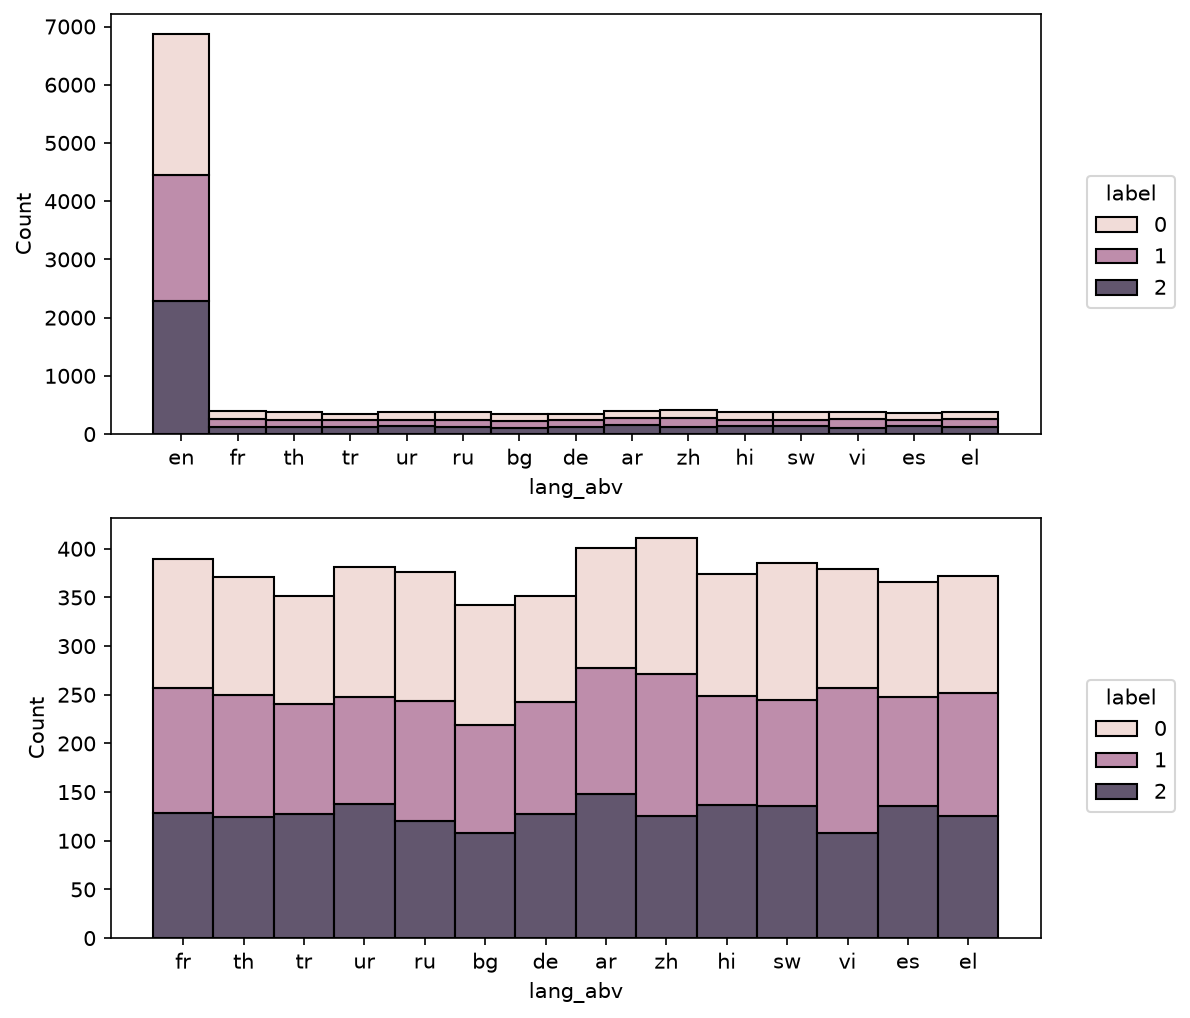

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), dpi=150)

sns.histplot(origin_df, 
             x='lang_abv', 
             hue='label', 
             multiple='stack',
             ax=axes[0])
sns.move_legend(axes[0], loc=(1.05, 0.3))

sns.histplot(origin_df[origin_df['lang_abv'] != 'en'], 
             x='lang_abv', 
             hue='label', 
             multiple='stack',
             ax=axes[1])
sns.move_legend(axes[1], loc=(1.05, 0.3))

# **2. Обучение моделей**

Будем обучать **1 мультиязычную модель microsoft/mdeberta-v3-base**

## **2.1. Подготовка данных**

Подготовим данные. Выберем только английские текста, удалим лишние колонки. Уменьшим суммарную длину premise и hypothesis, чтобы они влезли в ограничение **1200** символов. Разделим данные на обучающую и тестовую выборки.

In [8]:
df = origin_df.drop(['id','language'], axis=1)
df = df.apply(lambda x: prepare_data(x, 1200), axis=1)
df_training, df_testing = train_test_split(df, 
                                           test_size=0.15, 
                                           random_state=101, 
                                           stratify=df[['label', 'lang_abv']])

## **2.2. Подготовка модели**

In [9]:
#Загрузка мультиязычной модели
tokenizer = AutoTokenizer.from_pretrained('microsoft/mdeberta-v3-base', use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained('microsoft/mdeberta-v3-base', num_labels=3)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.dense.bias                | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
classifier.weight   

In [10]:
#Подготовка токенов
data_train = Dataset.from_pandas(df_training)
data_test = Dataset.from_pandas(df_testing)

data_train = data_train.map(lambda x: tokenize(tokenizer, x), batched=True)
data_test = data_test.map(lambda x: tokenize(tokenizer, x), batched=True)

Map:   0%|          | 0/10302 [00:00<?, ? examples/s]

Map:   0%|          | 0/1818 [00:00<?, ? examples/s]

In [11]:
#Подготовка модели
training_args = TrainingArguments(output_dir='./mdeberta_cache',
                                  per_device_train_batch_size=16,
                                  num_train_epochs=3,
                                  learning_rate=2e-5,
                                  weight_decay=0.01,
                                  torch_empty_cache_steps=10,
                                  logging_steps=1,
                                  report_to='none',
                                  eval_strategy='epoch',
                                  per_device_eval_batch_size=16,
                                  save_strategy='epoch',
                                  load_best_model_at_end=True,
                                  metric_for_best_model='accuracy',
                                  seed=101)

trainer = Trainer(model=model,
                  args=training_args,
                  train_dataset=data_train,
                  eval_dataset=data_test,
                  compute_metrics=metrics)

## **2.3. Обучение модели**

In [ ]:
#Начинаем обучение модели
trainer.train()

C:\Users\SMD\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
#Сохраняем финальную лучшую модель
trainer.save_model('./best_mdeberta_model')